In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import ks_2samp

In [2]:
X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

columns = [f"feature_{i}" for i in range(X.shape[1])]
df_original = pd.DataFrame(X, columns=columns)
df_original["target"] = y

df_original.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,3.316690,-2.029674,2.355629,-0.215829,-1.419279,0.914109,-5.980685,1.518092,-0.042540,-3.397662,0
1,4.161930,-3.898558,0.174588,-0.091221,-1.360185,-0.606968,-4.648657,-2.454777,-0.667688,-0.629240,0
2,-0.477509,3.103860,2.694822,1.562327,4.191341,1.230190,3.491643,0.827346,0.635312,-2.593035,0
3,-1.894990,2.218811,-0.062834,-2.495924,-1.738007,-1.256467,-1.842087,1.668228,0.494795,-0.994083,0
4,-0.101203,0.444587,-0.793103,-2.204839,3.360553,0.922288,0.683308,-1.889515,-1.772399,1.312052,1


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df_original.drop("target", axis=1),
    df_original["target"],
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

baseline_preds = model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.921


In [4]:
df_drifted = df_original.copy()

drift_features = ["feature_0", "feature_1", "feature_2"]

for col in drift_features:
    df_drifted[col] = df_drifted[col] + np.random.normal(2.5, 1.0, size=len(df_drifted))

X_drifted = df_drifted.drop("target", axis=1)
y_drifted = df_drifted["target"]

drift_preds = model.predict(X_drifted)
drift_accuracy = accuracy_score(y_drifted, drift_preds)

print("Accuracy After Drift:", drift_accuracy)

Accuracy After Drift: 0.946


In [5]:
def detect_drift_ks(reference_data, current_data, threshold=0.05):
    drift_report = []

    for col in reference_data.columns:
        stat, p_value = ks_2samp(reference_data[col], current_data[col])
        drift_detected = p_value < threshold

        drift_report.append({
            "feature": col,
            "ks_statistic": stat,
            "p_value": p_value,
            "drift_detected": drift_detected
        })

    return pd.DataFrame(drift_report)

drift_report = detect_drift_ks(
    X_train,
    X_drifted[X_train.columns]
)

drift_report

,feature,ks_statistic,p_value,drift_detected
0,feature_0,0.37765,9.143791e-283,True
1,feature_1,0.50030,0.000000e+00,True
2,feature_2,0.70565,0.000000e+00,True
3,feature_3,0.00860,9.961843e-01,False
4,feature_4,0.00690,9.999165e-01,False
5,feature_5,0.00590,9.999985e-01,False
6,feature_6,0.00780,9.991315e-01,False
7,feature_7,0.00545,9.999999e-01,False
8,feature_8,0.00555,9.999998e-01,False
9,feature_9,0.00710,9.998478e-01,False


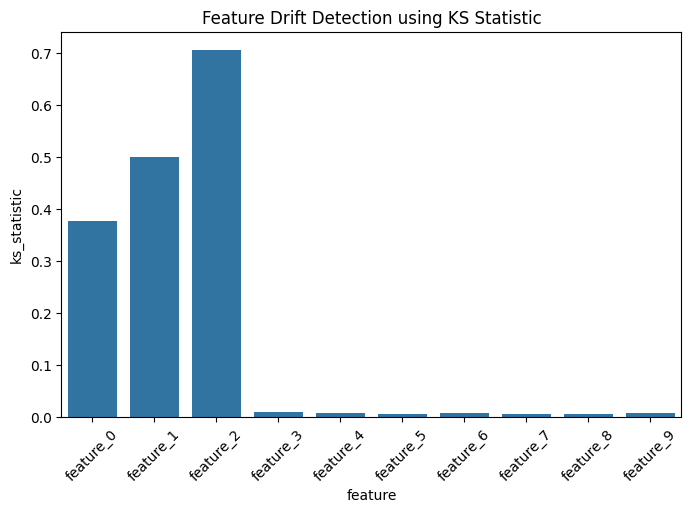

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=drift_report, x="feature", y="ks_statistic")
plt.xticks(rotation=45)
plt.title("Feature Drift Detection using KS Statistic")
plt.show()

In [7]:
if drift_report["drift_detected"].sum() > 0:
    print("Drift detected. Retraining model...")

    X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(
        X_drifted,
        y_drifted,
        test_size=0.2,
        random_state=42
    )

    retrained_model = RandomForestClassifier(random_state=42)
    retrained_model.fit(X_new_train, y_new_train)

    retrained_preds = retrained_model.predict(X_new_test)
    retrained_accuracy = accuracy_score(y_new_test, retrained_preds)

    print("Retrained Accuracy:", retrained_accuracy)
else:
    print("No significant drift detected.")

Drift detected. Retraining model...
Retrained Accuracy: 0.907


In [8]:
results = pd.DataFrame({
    "Stage": ["Baseline", "After Drift", "After Retraining"],
    "Accuracy": [baseline_accuracy, drift_accuracy, retrained_accuracy]
})

results

,Stage,Accuracy
0,Baseline,0.921
1,After Drift,0.946
2,After Retraining,0.907


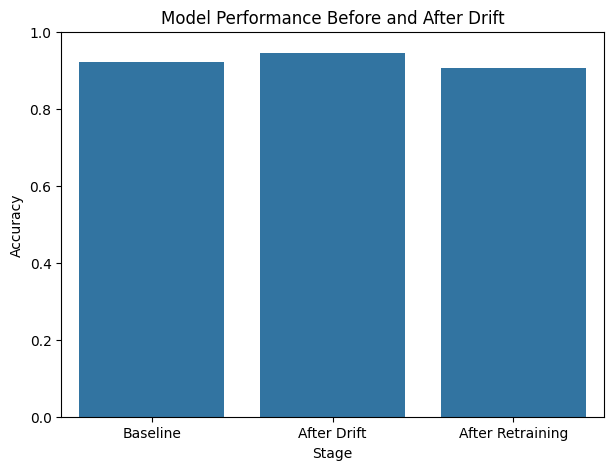

In [9]:
plt.figure(figsize=(7, 5))
sns.barplot(data=results, x="Stage", y="Accuracy")
plt.title("Model Performance Before and After Drift")
plt.ylim(0, 1)
plt.show()

In [10]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
matplotlib
seaborn
scipy
joblib

Writing requirements.txt


In [11]:
%%writefile README.md
# Concept Drift Detection and Adaptive Retraining Pipeline

## Overview
This project demonstrates how machine learning models can lose performance when data distribution changes over time, known as concept drift or data drift.

## Features
- Baseline model training
- Simulated data drift
- Drift detection using KS Test
- Model performance comparison
- Adaptive retraining when drift is detected
- Visualizations for drift and accuracy changes

## Tech Stack
Python, Pandas, NumPy, Scikit-learn, Scipy, Matplotlib, Seaborn

## Workflow
1. Generate synthetic classification dataset
2. Train a baseline Random Forest model
3. Simulate drift in selected features
4. Detect drift using Kolmogorov-Smirnov Test
5. Compare model accuracy before and after drift
6. Retrain model when drift is detected

## How to Run
Open the notebook in Google Colab and run all cells.

## Expected Output
The notebook shows:
- Baseline accuracy
- Accuracy after drift
- Drift report
- Accuracy after adaptive retraining
- Visualizations comparing model performance

Writing README.md
